# Bài toán 4: Dự đoán Thời gian Chuyến xe (Trip Duration)

## Mục đích
- Dự đoán thời gian chuyến xe (trip_duration) dựa trên các đặc trưng
- Sử dụng output từ các bài toán trước: `cluster_id`, `behavior_cluster`
- So sánh nhiều mô hình ML Regressor và chọn mô hình tốt nhất

## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import gc, time
try:
    import psutil
    PSUTIL_AVAILABLE = True
except Exception:
    PSUTIL_AVAILABLE = False

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, RandomizedSearchCV, HalvingRandomSearchCV
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error,
)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

## 2. Load dữ liệu

In [4]:
df = pd.read_csv('../data/raw/yellow_tripdata_2016-03_processed.csv')

print(f"Dữ liệu loaded: {df.shape}")
print(f"Các cột trong dataset: {df.columns.tolist()}")
print(f"\nTrip duration stats:")
print(df['trip_duration'].describe())

Dữ liệu loaded: (11411918, 25)
Các cột trong dataset: ['Unnamed: 0', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'fare_amount', 'trip_duration', 'speed', 'pickup_hour', 'pickup_dayofweek', 'pickup_month', 'time_of_day', 'is_peak_hour', 'is_credit_card', 'total_income', 'location_cluster', 'fare_per_miles', 'fare_per_min', 'traffic_index', 'traffic_level', 'behavior_cluster']

Trip duration stats:
count    1.141192e+07
mean     7.471010e+02
std      4.733584e+02
min      6.100000e+01
25%      3.900000e+02
50%      6.350000e+02
75%      9.950000e+02
max      2.655000e+03
Name: trip_duration, dtype: float64


## 3. Sử dụng cluster_id

In [5]:
# Sử dụng output từ bài toán cluster
print("Sử dụng cluster_id từ output của bài toán cluster...")

# File yellow_tripdata_2016-03_processed.csv đã được tạo từ cluster.ipynb
# và chứa cột location_cluster
if 'location_cluster' in df.columns:
    df['cluster_id'] = df['location_cluster'].copy()
    df = df.drop('location_cluster', axis=1)
    print(f"✅ Sử dụng location_cluster từ output bài toán cluster")
elif 'cluster_id' not in df.columns:
    raise ValueError('Không tìm thấy cột cluster_id hoặc location_cluster trong dữ liệu.')

print(f"✅ Cluster_id loaded")
print(f"Cluster distribution:\n{df['cluster_id'].value_counts().sort_index()}")


Sử dụng cluster_id từ output của bài toán cluster...
✅ Sử dụng location_cluster từ output bài toán cluster
✅ Cluster_id loaded
Cluster distribution:
cluster_id
-1      454574
 0    10668458
 1      238536
 2       27468
 3       10107
 4       12775
Name: count, dtype: int64


## 4. Sử dụng behavior_cluster

In [6]:
# Behavior cluster đã có sẵn trong file processed — kiểm tra và chuẩn hoá
if 'behavior_cluster' not in df.columns:
    raise ValueError("Không tìm thấy cột behavior_cluster.")

# Cảnh báo nếu có giá trị thiếu
missing = df['behavior_cluster'].isna().sum() if 'behavior_cluster' in df.columns else 0
if missing > 0:
    print("f")

# Dùng nullable integer type để giữ NA nếu cần
try:
    df['behavior_cluster'] = df['behavior_cluster'].astype('Int64')
except Exception:
    df['behavior_cluster'] = pd.to_numeric(df['behavior_cluster'], errors='coerce').astype('Int64')

print("Behavior_cluster có sẵn")

Behavior_cluster có sẵn


## 5. Chuẩn bị Features cho Regressor

In [7]:
feature_cols = [
    'trip_distance',
    'pickup_longitude', 
    'pickup_latitude',
    'dropoff_longitude', 
    'dropoff_latitude',
    'cluster_id',
    'behavior_cluster',
    'passenger_count'
]

# Kiểm tra features có sẵn
available_features = [f for f in feature_cols if f in df.columns]
print(f"Features sử dụng ({len(available_features)}): {available_features}")

X = df[available_features].copy()
y = df['trip_duration'].copy()

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeature stats:")
print(X.describe())

Features sử dụng (8): ['trip_distance', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'cluster_id', 'behavior_cluster', 'passenger_count']

X shape: (11411918, 8)
y shape: (11411918,)

Feature stats:
       trip_distance  pickup_longitude  pickup_latitude  dropoff_longitude  \
count   1.141192e+07      1.141192e+07     1.141192e+07       1.141192e+07   
mean    2.433433e+00     -7.397761e+01     4.075276e+01      -7.397535e+01   
std     2.267391e+00      2.712710e-02     2.407487e-02       2.747731e-02   
min     1.100000e-01     -7.414575e+01     4.057748e+01      -7.414951e+01   
25%     1.000000e+00     -7.399213e+01     4.073857e+01      -7.399142e+01   
50%     1.650000e+00     -7.398216e+01     4.075448e+01      -7.398017e+01   
75%     2.900000e+00     -7.396909e+01     4.076815e+01      -7.396438e+01   
max     1.326000e+01     -7.370239e+01     4.091751e+01      -7.370040e+01   

       dropoff_latitude    cluster_id  behavior_cluster  passen

## 6. Train/Test Split

In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Split temp (30%) into validation (50% of temp = 15%) and test (50% of temp = 15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Training set: {X_train.shape} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape} ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTarget distribution:")
print(f"Train - Mean: {y_train.mean():.2f}s, Std: {y_train.std():.2f}s")
print(f"Val   - Mean: {y_val.mean():.2f}s, Std: {y_val.std():.2f}s")
print(f"Test  - Mean: {y_test.mean():.2f}s, Std: {y_test.std():.2f}s")

Training set: (7988342, 8) (70.0%)
Validation set: (1711788, 8) (15.0%)
Test set: (1711788, 8) (15.0%)

Target distribution:
Train - Mean: 747.26s, Std: 473.44s
Val   - Mean: 746.85s, Std: 473.05s
Test  - Mean: 746.59s, Std: 473.29s


## 7. Định nghĩa các mô hình Regressor

In [9]:
# Định nghĩa các mô hình với thông tin về scaling requirement
# Tree-based models (LightGBM, CatBoost, XGBoost) do NOT require feature scaling
models = {
    'LightGBM': (LGBMRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, 
                                num_leaves=31, random_state=42, n_jobs=-1, verbose=-1), False),
    'CatBoost': (CatBoostRegressor(iterations=100, max_depth=6, learning_rate=0.1,
                                   random_state=42, thread_count=-1, verbose=False), False),
    'XGBoost': (XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1,
                             random_state=42, n_jobs=-1, tree_method='hist', verbosity=0), False)
}

print(f"{len(models)} mô hình đã được định nghĩa:")
for name in models.keys():
    print(f"  - {name}")

3 mô hình đã được định nghĩa:
  - LightGBM
  - CatBoost
  - XGBoost


## 8. Chuẩn bị Scaler

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"   X_train shape: {X_train.shape}")
print(f"   X_val shape: {X_val.shape}")
print(f"   X_test shape: {X_test.shape}")

   X_train shape: (7988342, 8)
   X_val shape: (1711788, 8)
   X_test shape: (1711788, 8)


## 9. Training và Evaluation Models

In [11]:
results = {}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

print("="*80)
print("TRAINING VÀ ĐÁNH GIÁ CÁC MÔ HÌNH")
print("="*80)

for name, (model, needs_scaling) in models.items():
    print(f"\n Training {name}...", end=' ', flush=True)
    
    # Chọn dữ liệu scaled hay không
    X_tr = X_train_scaled if needs_scaling else X_train
    X_v = X_val_scaled if needs_scaling else X_val
    X_te = X_test_scaled if needs_scaling else X_test
    
    model.fit(X_tr, y_train)
    
    # Dự đoán
    y_pred_train = model.predict(X_tr)
    y_pred_val = model.predict(X_v)
    y_pred_test = model.predict(X_te)
    
    val_mse = mean_squared_error(y_val, y_pred_val)
    val_rmse = np.sqrt(val_mse)
    val_mae = mean_absolute_error(y_val, y_pred_val)
    val_r2 = r2_score(y_val, y_pred_val)
    val_mape = mean_absolute_percentage_error(y_val, y_pred_val)
    
    test_mse = mean_squared_error(y_test, y_pred_test)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_r2 = r2_score(y_test, y_pred_test)
    test_mape = mean_absolute_percentage_error(y_test, y_pred_test)
    
    cv_scores = cross_val_score(model, X_tr, y_train, cv=cv, 
                                  scoring='neg_mean_squared_error', n_jobs=-1)
    cv_rmse = np.sqrt(-cv_scores.mean())
    
    results[name] = {
        'model': model,
        'scaled': needs_scaling,
        'train_rmse': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'val_rmse': val_rmse,
        'val_mae': val_mae,
        'val_r2': val_r2,
        'val_mape': val_mape,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'test_mape': test_mape,
        'cv_rmse': cv_rmse,
        'cv_rmse_std': np.sqrt(cv_scores.std()),
        'y_pred_val': y_pred_val,
        'y_pred_test': y_pred_test
    }
    
    print(f"")
    print(f"  Val  - RMSE: {val_rmse:.2f}s | MAE: {val_mae:.2f}s | R²: {val_r2:.4f} | MAPE: {val_mape:.2%}")
    print(f"  Test - RMSE: {test_rmse:.2f}s | MAE: {test_mae:.2f}s | R²: {test_r2:.4f} | MAPE: {test_mape:.2%}")
    print(f"  CV RMSE (on train): {cv_rmse:.2f}s (±{np.sqrt(cv_scores.std()):.2f}s)")

print("\n" + "="*80)
print("Tất cả mô hình đã được huấn luyện!")
print("="*80)

TRAINING VÀ ĐÁNH GIÁ CÁC MÔ HÌNH

 Training LightGBM... 
  Val  - RMSE: 170.28s | MAE: 115.99s | R²: 0.8704 | MAPE: 16.70%
  Test - RMSE: 169.96s | MAE: 115.90s | R²: 0.8710 | MAPE: 16.71%
  CV RMSE (on train): 170.25s (±8.77s)

 Training CatBoost... 
  Val  - RMSE: 173.18s | MAE: 117.74s | R²: 0.8660 | MAPE: 16.98%
  Test - RMSE: 172.89s | MAE: 117.65s | R²: 0.8666 | MAPE: 16.97%
  CV RMSE (on train): 173.24s (±9.47s)

 Training XGBoost... 
  Val  - RMSE: 169.59s | MAE: 115.36s | R²: 0.8715 | MAPE: 16.53%
  Test - RMSE: 169.23s | MAE: 115.25s | R²: 0.8721 | MAPE: 16.53%
  CV RMSE (on train): 169.42s (±8.77s)

Tất cả mô hình đã được huấn luyện!


## 10. So sánh kết quả và chọn mô hình tốt nhất

In [12]:
# Tạo dataframe để so sánh các mô hình
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train RMSE': [results[m]['train_rmse'] for m in results.keys()],
    'Val RMSE': [results[m]['val_rmse'] for m in results.keys()],
    'Val MAE': [results[m]['val_mae'] for m in results.keys()],
    'Val R²': [results[m]['val_r2'] for m in results.keys()],
    'Val MAPE': [results[m]['val_mape'] for m in results.keys()],
    'Test RMSE': [results[m]['test_rmse'] for m in results.keys()],
    'Test MAE': [results[m]['test_mae'] for m in results.keys()],
    'Test R²': [results[m]['test_r2'] for m in results.keys()],
    'Test MAPE': [results[m]['test_mape'] for m in results.keys()],
})

# Sắp xếp theo Val RMSE
comparison_df = comparison_df.sort_values('Val RMSE').reset_index(drop=True)

print("\n BẢNG SO SÁNH KẾT QUẢ CÁC MÔ HÌNH (VALIDATION SET)")
print("="*140)
print(comparison_df.to_string(index=False))
print("="*140)

# Chọn mô hình tốt nhất
best_model_name = comparison_df.iloc[0]['Model']
best_val_rmse = comparison_df.iloc[0]['Val RMSE']
best_val_r2 = comparison_df.iloc[0]['Val R²']
best_test_rmse = comparison_df.iloc[0]['Test RMSE']
best_test_r2 = comparison_df.iloc[0]['Test R²']

print(f"\n MÔ HÌNH TỐT NHẤT (Validation set): {best_model_name}")
print(f"  Val RMSE: {best_val_rmse:.2f}s | Val R²: {best_val_r2:.4f}")
print(f"  Test RMSE: {best_test_rmse:.2f}s | Test R²: {best_test_r2:.4f}")


 BẢNG SO SÁNH KẾT QUẢ CÁC MÔ HÌNH (VALIDATION SET)
   Model  Train RMSE   Val RMSE    Val MAE   Val R²  Val MAPE  Test RMSE   Test MAE  Test R²  Test MAPE
 XGBoost  169.299202 169.593956 115.355408 0.871472  0.165317 169.231103 115.251240 0.872148   0.165322
LightGBM  170.086494 170.281675 115.989201 0.870427  0.167042 169.957075 115.903856 0.871049   0.167108
CatBoost  173.101051 173.175574 117.740541 0.865986  0.169764 172.890952 117.648117 0.866559   0.169733

 MÔ HÌNH TỐT NHẤT (Validation set): XGBoost
  Val RMSE: 169.59s | Val R²: 0.8715
  Test RMSE: 169.23s | Test R²: 0.8721


## 10.1. Hyperparameter Tuning cho các Model

In [13]:
print("="*80)
print("HYPERPARAMETER TUNING CHO CÁC MODEL")
print("="*80)

import math

tuned_models = {}
tuning_sample_size = 10000
tuning_rng = np.random.default_rng(42)

param_grids = {
    'LightGBM': {
        'n_estimators': [80, 100, 150],
        'max_depth': [4, 6, 10],
        'learning_rate': [0.05, 0.1],
        'num_leaves': [20, 31, 50],
        'min_child_samples': [10, 20]
    },
    'CatBoost': {
        'iterations': [80, 100, 150],
        'max_depth': [4, 6, 10],
        'learning_rate': [0.05, 0.1],
        'l2_leaf_reg': [1, 3, 5],
        'subsample': [0.8, 1.0]
    },
    'XGBoost': {
        'n_estimators': [100, 150],
        'max_depth': [4, 6],
        'learning_rate': [0.05, 0.1],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }
}

for model_name in models.keys():
    if model_name not in param_grids:
        print(f"⚠️ {model_name} không có tham số tuning được định nghĩa")
        continue
    
    print(f"\n Tuning {model_name}...", flush=True)
    
    # Lấy model base từ results
    base_model = results[model_name]['model']
    needs_scaling = results[model_name]['scaled']
    
    # Chọn dữ liệu scaled hay không
    X_tr = X_train_scaled if needs_scaling else X_train
    X_v = X_val_scaled if needs_scaling else X_val
    X_te = X_test_scaled if needs_scaling else X_test
    
    # Tuning trên một mẫu giới hạn của training set để tránh MemoryError
    n_rows = len(X_tr)
    sample_size = min(tuning_sample_size, n_rows)
    if sample_size < n_rows:
        sample_indices = tuning_rng.choice(n_rows, size=sample_size, replace=False)
        if hasattr(X_tr, 'iloc'):
            X_tune = X_tr.iloc[sample_indices]
        else:
            X_tune = X_tr[sample_indices]
        if hasattr(y_train, 'iloc'):
            y_tune = y_train.iloc[sample_indices]
        else:
            y_tune = y_train[sample_indices]
    else:
        X_tune = X_tr
        y_tune = y_train
    
    if hasattr(X_tune, 'to_numpy'):
        X_tune_np = X_tune.to_numpy(dtype=np.float32)
    else:
        X_tune_np = np.asarray(X_tune, dtype=np.float32)
    if hasattr(y_tune, 'to_numpy'):
        y_tune_np = y_tune.to_numpy(dtype=np.float32)
    else:
        y_tune_np = np.asarray(y_tune, dtype=np.float32)


    try:
        searcher = HalvingRandomSearchCV(
            estimator=base_model,
            param_distributions=param_grids[model_name],
            factor=3,
            cv=3,
            scoring='neg_mean_squared_error',
            n_jobs=-1,
            random_state=42,
            verbose=1
        )
        search_kind = 'halving'
    except Exception:
        searcher = RandomizedSearchCV(
            estimator=base_model,
            param_distributions=param_grids[model_name],
            n_iter=25,
            cv=3,
            scoring='neg_mean_squared_error',
            n_jobs=-1,
            pre_dispatch='2*n_jobs',
            random_state=42,
            verbose=1
        )
        search_kind = 'randomized'

    if PSUTIL_AVAILABLE:
        proc = psutil.Process()
        mem_before = proc.memory_info().rss / (1024**2)
        print(f"Memory before search ({search_kind}): {mem_before:.1f} MiB")

    t0 = time.perf_counter()
    try:
        searcher.fit(X_tune_np, y_tune_np)
    finally:
        elapsed = time.perf_counter() - t0
    
    if PSUTIL_AVAILABLE:
        mem_after = proc.memory_info().rss / (1024**2)
        print(f"Memory after search: {mem_after:.1f} MiB (Δ {mem_after-mem_before:.1f} MiB)")

    print(f"  Search kind: {search_kind} | elapsed: {elapsed:.1f}s | best_score: {searcher.best_score_}")

    # Refit model tốt nhất trên toàn bộ training split
    best_params = searcher.best_params_
    best_model_tuned = clone(base_model).set_params(**best_params)
    best_model_tuned.fit(X_tr, y_train)

    y_pred_train_tuned = best_model_tuned.predict(X_tr)
    y_pred_val_tuned = best_model_tuned.predict(X_v)
    y_pred_test_tuned = best_model_tuned.predict(X_te)

    val_rmse_tuned = np.sqrt(mean_squared_error(y_val, y_pred_val_tuned))
    val_mae_tuned = mean_absolute_error(y_val, y_pred_val_tuned)
    val_r2_tuned = r2_score(y_val, y_pred_val_tuned)
    val_mape_tuned = mean_absolute_percentage_error(y_val, y_pred_val_tuned)

    test_rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_test_tuned))
    test_mae_tuned = mean_absolute_error(y_test, y_pred_test_tuned)
    test_r2_tuned = r2_score(y_test, y_pred_test_tuned)
    test_mape_tuned = mean_absolute_percentage_error(y_test, y_pred_test_tuned)

    train_rmse_tuned = np.sqrt(mean_squared_error(y_train, y_pred_train_tuned))

    tuned_models[model_name] = {
        'model': best_model_tuned,
        'scaled': needs_scaling,
        'best_params': best_params,
        'best_cv_score': np.sqrt(-searcher.best_score_),
        'train_rmse': train_rmse_tuned,
        'val_rmse': val_rmse_tuned,
        'val_mae': val_mae_tuned,
        'val_r2': val_r2_tuned,
        'val_mape': val_mape_tuned,
        'test_rmse': test_rmse_tuned,
        'test_mae': test_mae_tuned,
        'test_r2': test_r2_tuned,
        'test_mape': test_mape_tuned,
        'y_pred_val': y_pred_val_tuned,
        'y_pred_test': y_pred_test_tuned
    }

    print(f"   Tuning hoàn tất for {model_name}!")
    print(f"   Best params: {best_params}")
    print(f"   CV RMSE (on train sample): {np.sqrt(-searcher.best_score_):.2f}s")
    print(f"   Val RMSE: {val_rmse_tuned:.2f}s | MAE: {val_mae_tuned:.2f}s | R²: {val_r2_tuned:.4f}")
    print(f"   Test RMSE: {test_rmse_tuned:.2f}s | MAE: {test_mae_tuned:.2f}s | R²: {test_r2_tuned:.4f}")

    try:
        del X_tune, y_tune, X_tune_np, y_tune_np, searcher
    except Exception:
        pass
    gc.collect()

print("\n" + "="*80)
print(" Tuning hoàn tất cho tất cả các model!")
print("="*80)

HYPERPARAMETER TUNING CHO CÁC MODEL

 Tuning LightGBM...
Memory before search (halving): 2075.4 MiB
n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 7
min_resources_: 6
max_resources_: 10000
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 108
n_resources: 6
Fitting 3 folds for each of 108 candidates, totalling 324 fits
----------
iter: 1
n_candidates: 36
n_resources: 18
Fitting 3 folds for each of 36 candidates, totalling 108 fits
----------
iter: 2
n_candidates: 12
n_resources: 54
Fitting 3 folds for each of 12 candidates, totalling 36 fits
----------
iter: 3
n_candidates: 4
n_resources: 162
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 4
n_candidates: 2
n_resources: 486
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Memory after search: 2081.6 MiB (Δ 6.2 MiB)
  Search kind: halving | elapsed: 3.7s | best_score: -61238.964256395324
   Tuning hoàn tất for LightGBM!
   Best params: {'num_leaves': 20, 'n_e

## 10.2. So Sánh Kết Quả Trước và Sau Tuning

In [14]:
# Tạo dataframe so sánh trước và sau tuning
comparison_tuning = []

for model_name in models.keys():
    if model_name not in tuned_models:
        continue
    
    # Kết quả trước tuning (using validation set)
    before = comparison_df[comparison_df['Model'] == model_name].iloc[0]
    
    # Kết quả sau tuning
    after = tuned_models[model_name]
    
    comparison_tuning.append({
        'Model': model_name,
        'Before Val RMSE': before['Val RMSE'],
        'After Val RMSE': after['val_rmse'],
        'Val RMSE Improvement (%)': ((before['Val RMSE'] - after['val_rmse']) / before['Val RMSE'] * 100),
        'Before Val R²': before['Val R²'],
        'After Val R²': after['val_r2'],
        'Val R² Improvement': (after['val_r2'] - before['Val R²']),
        'Test RMSE': after['test_rmse'],
        'Test R²': after['test_r2']
    })

comparison_tuning_df = pd.DataFrame(comparison_tuning)

print("\n BẢNG SO SÁNH KẾT QUẢ TRƯỚC VÀ SAU TUNING (VALIDATION SET)")
print("="*160)
print(comparison_tuning_df.to_string(index=False))
print("="*160)

# Chọn model tốt nhất sau tuning (based on validation set)
best_tuned_model_name = comparison_tuning_df.loc[comparison_tuning_df['After Val RMSE'].idxmin(), 'Model']
best_tuned_val_rmse = comparison_tuning_df.loc[comparison_tuning_df['After Val RMSE'].idxmin(), 'After Val RMSE']
best_tuned_val_r2 = comparison_tuning_df.loc[comparison_tuning_df['After Val RMSE'].idxmin(), 'After Val R²']
best_tuned_test_rmse = comparison_tuning_df.loc[comparison_tuning_df['After Val RMSE'].idxmin(), 'Test RMSE']
best_tuned_test_r2 = comparison_tuning_df.loc[comparison_tuning_df['After Val RMSE'].idxmin(), 'Test R²']
val_improvement = comparison_tuning_df.loc[comparison_tuning_df['After Val RMSE'].idxmin(), 'Val RMSE Improvement (%)']

print(f"\n MÔ HÌNH TỐT NHẤT SAU TUNING (based on Validation set): {best_tuned_model_name}")
print(f"  Validation Set:")
print(f"    - Val RMSE: {best_tuned_val_rmse:.2f}s")
print(f"    - Val R²: {best_tuned_val_r2:.4f}")
print(f"    - Cải thiện RMSE: {val_improvement:.2f}%")
print(f"  Test Set (held out for final evaluation):")
print(f"    - Test RMSE: {best_tuned_test_rmse:.2f}s")
print(f"    - Test R²: {best_tuned_test_r2:.4f}")
print(f"\n  Best Hyperparameters:")
for param, value in tuned_models[best_tuned_model_name]['best_params'].items():
    print(f"    - {param}: {value}")


 BẢNG SO SÁNH KẾT QUẢ TRƯỚC VÀ SAU TUNING (VALIDATION SET)
   Model  Before Val RMSE  After Val RMSE  Val RMSE Improvement (%)  Before Val R²  After Val R²  Val R² Improvement  Test RMSE  Test R²
LightGBM       170.281675      169.876665                  0.237847       0.870427      0.871043            0.000616 169.540355 0.871681
CatBoost       173.175574      180.671114                 -4.328289       0.865986      0.854134           -0.011852 180.459569 0.854620
 XGBoost       169.593956      172.049659                 -1.447990       0.871472      0.867723           -0.003749 171.763020 0.868294

 MÔ HÌNH TỐT NHẤT SAU TUNING (based on Validation set): LightGBM
  Validation Set:
    - Val RMSE: 169.88s
    - Val R²: 0.8710
    - Cải thiện RMSE: 0.24%
  Test Set (held out for final evaluation):
    - Test RMSE: 169.54s
    - Test R²: 0.8717

  Best Hyperparameters:
    - num_leaves: 20
    - n_estimators: 150
    - min_child_samples: 10
    - max_depth: 10
    - learning_rate: 0.1


## 10.3. Visualization Kết Quả Tuning

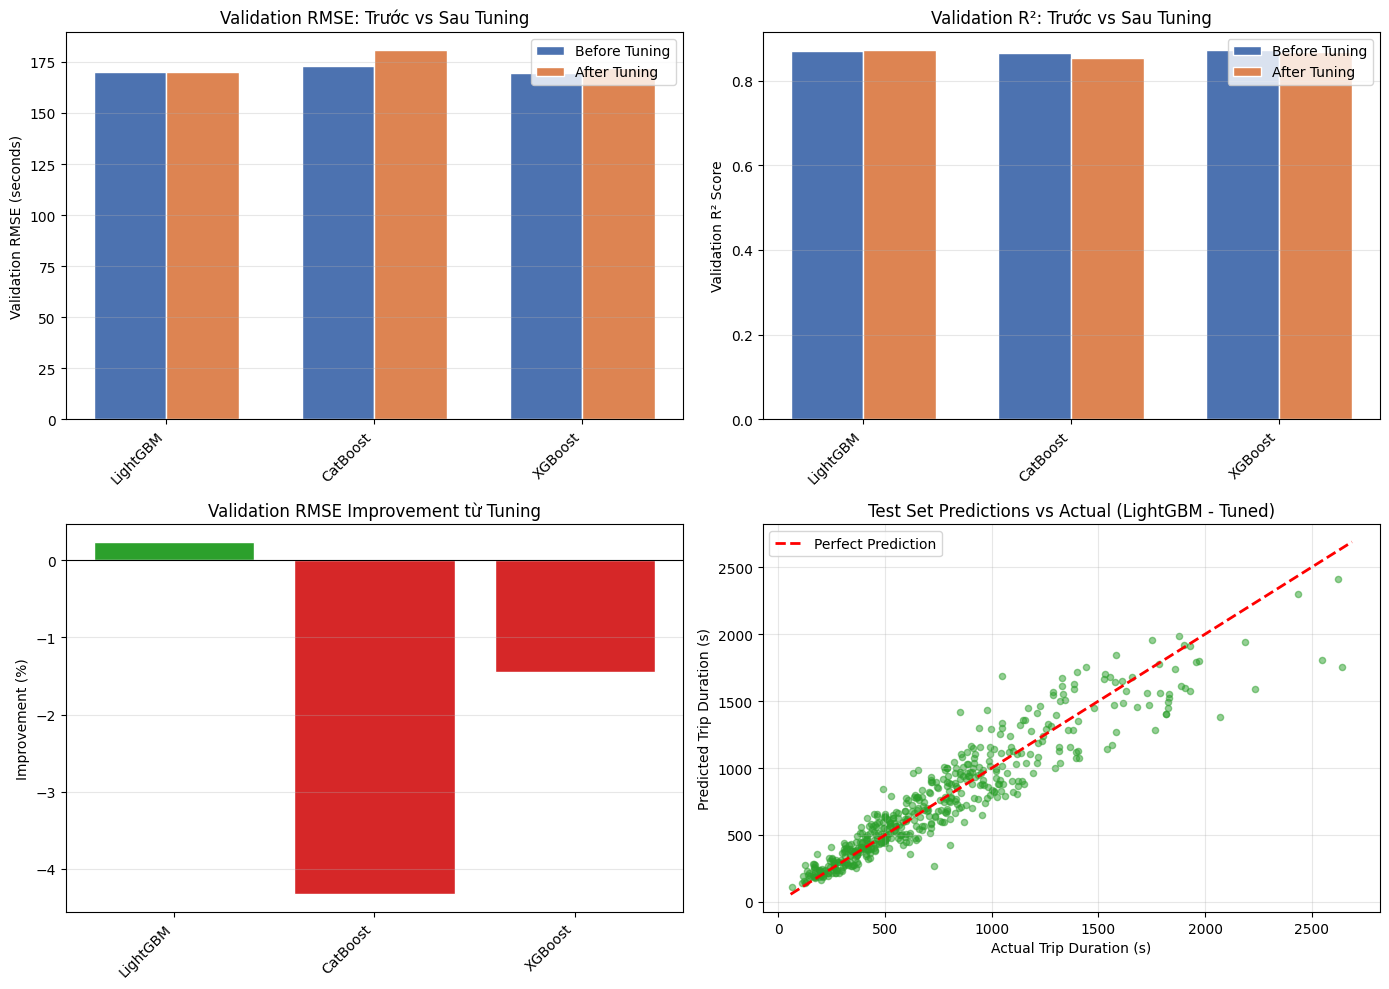

 Visualization saved as 'trip_duration_tuning_comparison.png'


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: RMSE Trước và Sau Tuning (Validation set)
models_tuning = comparison_tuning_df['Model']
x = np.arange(len(models_tuning))
width = 0.35

axes[0, 0].bar(x - width/2, comparison_tuning_df['Before Val RMSE'], width, 
               label='Before Tuning', color='#4C72B0', edgecolor='white')
axes[0, 0].bar(x + width/2, comparison_tuning_df['After Val RMSE'], width, 
               label='After Tuning', color='#DD8452', edgecolor='white')
axes[0, 0].set_ylabel('Validation RMSE (seconds)')
axes[0, 0].set_title('Validation RMSE: Trước vs Sau Tuning')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models_tuning, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: R² Trước và Sau Tuning (Validation set)
axes[0, 1].bar(x - width/2, comparison_tuning_df['Before Val R²'], width, 
               label='Before Tuning', color='#4C72B0', edgecolor='white')
axes[0, 1].bar(x + width/2, comparison_tuning_df['After Val R²'], width, 
               label='After Tuning', color='#DD8452', edgecolor='white')
axes[0, 1].set_ylabel('Validation R² Score')
axes[0, 1].set_title('Validation R²: Trước vs Sau Tuning')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models_tuning, rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: Cải thiện RMSE (%)
colors_improvement = ['#2CA02C' if x > 0 else '#D62728' for x in comparison_tuning_df['Val RMSE Improvement (%)']]
axes[1, 0].bar(models_tuning, comparison_tuning_df['Val RMSE Improvement (%)'], color=colors_improvement, edgecolor='white')
axes[1, 0].set_ylabel('Improvement (%)')
axes[1, 0].set_title('Validation RMSE Improvement từ Tuning')
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1, 0].set_xticklabels(models_tuning, rotation=45, ha='right')
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Actual vs Predicted cho best tuned model (using test set)
best_tuned_model = tuned_models[best_tuned_model_name]
y_pred_best_tuned = best_tuned_model['y_pred_test']

n_sample = min(500, len(y_test))
axes[1, 1].scatter(y_test.iloc[:n_sample], y_pred_best_tuned[:n_sample], 
                   alpha=0.5, s=20, color='#2CA02C')
min_val = min(y_test.min(), y_pred_best_tuned.min())
max_val = max(y_test.max(), y_pred_best_tuned.max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[1, 1].set_xlabel('Actual Trip Duration (s)')
axes[1, 1].set_ylabel('Predicted Trip Duration (s)')
axes[1, 1].set_title(f'Test Set Predictions vs Actual ({best_tuned_model_name} - Tuned)')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('trip_duration_tuning_comparison.png', bbox_inches='tight', dpi=100)
plt.show()

print(" Visualization saved as 'trip_duration_tuning_comparison.png'")

## 11. Visualize Model Performance

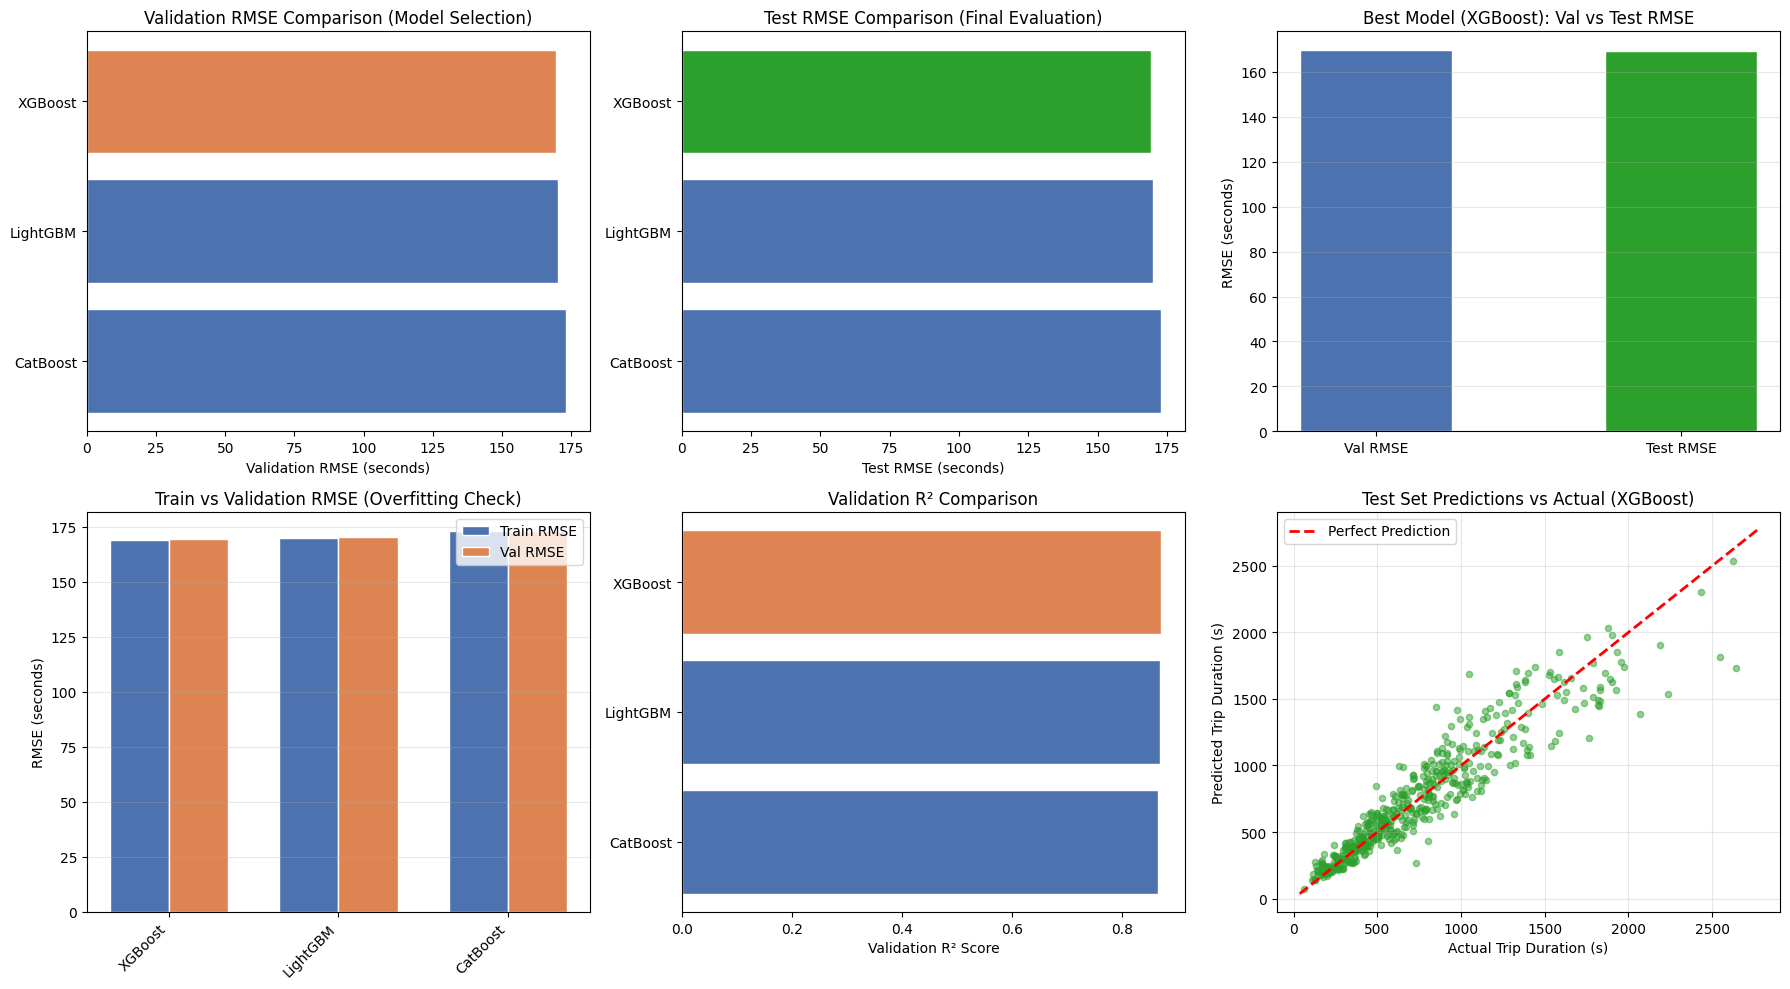

 Visualization saved as 'trip_duration_model_comparison.png'


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Validation RMSE comparison
comparison_sorted_val = comparison_df.sort_values('Val RMSE')
colors_val = ['#DD8452' if m == best_model_name else '#4C72B0' for m in comparison_sorted_val['Model']]
axes[0, 0].barh(comparison_sorted_val['Model'], comparison_sorted_val['Val RMSE'], color=colors_val, edgecolor='white')
axes[0, 0].set_xlabel('Validation RMSE (seconds)')
axes[0, 0].set_title('Validation RMSE Comparison (Model Selection)')
axes[0, 0].invert_yaxis()

# Plot 2: Test RMSE comparison (held-out evaluation)
comparison_sorted_test = comparison_df.sort_values('Test RMSE')
colors_test = ['#2CA02C' if m == best_model_name else '#4C72B0' for m in comparison_sorted_test['Model']]
axes[0, 1].barh(comparison_sorted_test['Model'], comparison_sorted_test['Test RMSE'], color=colors_test, edgecolor='white')
axes[0, 1].set_xlabel('Test RMSE (seconds)')
axes[0, 1].set_title('Test RMSE Comparison (Final Evaluation)')
axes[0, 1].invert_yaxis()

# Plot 3: Validation vs Test RMSE for best model
best_model_comparison = comparison_df[comparison_df['Model'] == best_model_name].iloc[0]
rmse_types = ['Val RMSE', 'Test RMSE']
rmse_values = [best_model_comparison['Val RMSE'], best_model_comparison['Test RMSE']]
colors_rmse = ['#4C72B0', '#2CA02C']
axes[0, 2].bar(rmse_types, rmse_values, color=colors_rmse, edgecolor='white', width=0.5)
axes[0, 2].set_ylabel('RMSE (seconds)')
axes[0, 2].set_title(f'Best Model ({best_model_name}): Val vs Test RMSE')
axes[0, 2].grid(axis='y', alpha=0.3)

# Plot 4: Train vs Validation RMSE (overfitting check on validation set)
models_to_plot = comparison_df['Model']
x = np.arange(len(models_to_plot))
width = 0.35

axes[1, 0].bar(x - width/2, comparison_df['Train RMSE'], width, label='Train RMSE', color='#4C72B0', edgecolor='white')
axes[1, 0].bar(x + width/2, comparison_df['Val RMSE'], width, label='Val RMSE', color='#DD8452', edgecolor='white')
axes[1, 0].set_ylabel('RMSE (seconds)')
axes[1, 0].set_title('Train vs Validation RMSE (Overfitting Check)')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models_to_plot, rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 5: Validation R² comparison
comparison_sorted_r2_val = comparison_df.sort_values('Val R²', ascending=False)
colors_r2_val = ['#DD8452' if m == best_model_name else '#4C72B0' for m in comparison_sorted_r2_val['Model']]
axes[1, 1].barh(comparison_sorted_r2_val['Model'], comparison_sorted_r2_val['Val R²'], color=colors_r2_val, edgecolor='white')
axes[1, 1].set_xlabel('Validation R² Score')
axes[1, 1].set_title('Validation R² Comparison')
axes[1, 1].invert_yaxis()

# Plot 6: Predictions vs Actual (Best Model - using test set)
best_model_results = results[best_model_name]
y_pred_best_test = best_model_results['y_pred_test']

# Plot first 500 predictions for clarity
n_sample = min(500, len(y_test))
axes[1, 2].scatter(y_test.iloc[:n_sample], y_pred_best_test[:n_sample], alpha=0.5, s=20, color='#2CA02C')
min_val = min(y_test.min(), y_pred_best_test.min())
max_val = max(y_test.max(), y_pred_best_test.max())
axes[1, 2].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[1, 2].set_xlabel('Actual Trip Duration (s)')
axes[1, 2].set_ylabel('Predicted Trip Duration (s)')
axes[1, 2].set_title(f'Test Set Predictions vs Actual ({best_model_name})')
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('trip_duration_model_comparison.png', bbox_inches='tight', dpi=100)
plt.show()

print(" Visualization saved as 'trip_duration_model_comparison.png'")

## 12. Dự đoán Trip Duration cho toàn bộ Dataset

In [17]:
print(f"Dùng mô hình {best_tuned_model_name} (tuned) để dự đoán toàn bộ dataset...")
print(f"\n BEST MODEL (selected based on Validation set):")
print(f"  Validation Set : RMSE={best_tuned_val_rmse:.2f}s, R²={best_tuned_val_r2:.4f}")
print(f"  Test Set  (final evaluation): RMSE={best_tuned_test_rmse:.2f}s, R²={best_tuned_test_r2:.4f}")
print()

best_model = tuned_models[best_tuned_model_name]['model']
best_model_needs_scaling = tuned_models[best_tuned_model_name]['scaled']

# Prepare full data
X_full = df[available_features].copy()
if best_model_needs_scaling:
    X_full_scaled = scaler.transform(X_full)
    y_pred_full = best_model.predict(X_full_scaled)
else:
    y_pred_full = best_model.predict(X_full)

# Thêm cột prediction vào dataframe
df['predicted_trip_duration'] = y_pred_full

print(f" Dự đoán hoàn tất cho tất cả {len(df)} records!")
print(f"\nPredicted trip_duration statistics:")
print(df['predicted_trip_duration'].describe())
print(f"  Thực tế: {df['trip_duration'].mean():.2f}s")
print(f"  Dự đoán: {df['predicted_trip_duration'].mean():.2f}s")
print(f"\nSample predictions:")
sample_df = df[['trip_distance', 'behavior_cluster', 'cluster_id', 'trip_duration', 'predicted_trip_duration']].head(10)
print(sample_df)

Dùng mô hình LightGBM (tuned) để dự đoán toàn bộ dataset...

 BEST MODEL (selected based on Validation set):
  Validation Set : RMSE=169.88s, R²=0.8710
  Test Set  (final evaluation): RMSE=169.54s, R²=0.8717

 Dự đoán hoàn tất cho tất cả 11411918 records!

Predicted trip_duration statistics:
count    1.141192e+07
mean     7.471495e+02
std      4.397454e+02
min     -2.159276e+00
25%      4.057814e+02
50%      6.436338e+02
75%      1.005604e+03
max      2.688449e+03
Name: predicted_trip_duration, dtype: float64
  Thực tế: 747.10s
  Dự đoán: 747.15s

Sample predictions:
   trip_distance  behavior_cluster  cluster_id  trip_duration  \
0           2.50                 2           0          475.0   
1           2.90                 2           0          666.0   
2           6.20                 1          -1          963.0   
3           0.70                 0           0          299.0   
4           7.18                 1           0         1445.0   
5           0.54                 3  

## 13. Lưu kết quả

In [18]:
# Lưu dataframe với predictions
output_path = '../data/raw/taxi_with_predictions.csv'

# Chọn columns để lưu
save_cols = [
    'tpep_pickup_datetime', 'tpep_dropoff_datetime',
    'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude',
    'trip_distance', 'passenger_count',
    'trip_duration', 'predicted_trip_duration',
    'cluster_id', 'rush_hour'
]

save_cols = [c for c in save_cols if c in df.columns]
df_export = df[save_cols].copy()

df_export.to_csv(output_path, index=False)
print(f" Kết quả lưu vào: {output_path}")
print(f"   Số dòng: {len(df_export)}")
print(f"   Số cột: {len(df_export.columns)}")

# Lưu model evaluation report
report_path = '../data/raw/trip_duration_model_report.txt'
with open(report_path, 'w') as f:
    f.write("=" * 140 + "\n")
    f.write("TRIP DURATION PREDICTION - MODEL EVALUATION REPORT (70/15/15 SPLIT WITH HYPERPARAMETER TUNING)\n")
    f.write("=" * 140 + "\n\n")
    
    f.write("🏆 BEST MODEL AFTER TUNING (selected based on Validation set)\n")
    f.write("-" * 140 + "\n")
    f.write(f"Model Name: {best_tuned_model_name}\n")
    f.write(f"Validation Set Performance: RMSE={best_tuned_val_rmse:.2f}s, MAE={tuned_models[best_tuned_model_name]['val_mae']:.2f}s, R²={best_tuned_val_r2:.4f}\n")
    f.write(f"Test Set Performance (Final Evaluation): RMSE={best_tuned_test_rmse:.2f}s, MAE={tuned_models[best_tuned_model_name]['test_mae']:.2f}s, R²={best_tuned_test_r2:.4f}\n")
    f.write(f"Val MAPE: {tuned_models[best_tuned_model_name]['val_mape']:.2%}\n")
    f.write(f"Test MAPE: {tuned_models[best_tuned_model_name]['test_mape']:.2%}\n")
    f.write(f"Validation RMSE Improvement from Tuning: {val_improvement:.2f}%\n\n")
    
    f.write("Best Hyperparameters:\n")
    for param, value in tuned_models[best_tuned_model_name]['best_params'].items():
        f.write(f"  - {param}: {value}\n")
    f.write("\n")
    
    f.write("=" * 140 + "\n")
    f.write("DATA SPLIT INFORMATION (70/15/15)\n")
    f.write("-" * 140 + "\n")
    f.write(f"Training Set: {len(X_train)} records (70%) - used for model training and cross-validation during tuning\n")
    f.write(f"Validation Set: {len(X_val)} records (15%) - used for preliminary evaluation and model selection\n")
    f.write(f"Test Set: {len(X_test)} records (15%) - held out for final evaluation only\n\n")
    
    f.write("=" * 140 + "\n")
    f.write("ALL MODELS COMPARISON (BEFORE AND AFTER TUNING)\n")
    f.write("-" * 140 + "\n")
    f.write(comparison_tuning_df.to_string(index=False))
    f.write("\n\n")
    
    f.write("=" * 140 + "\n")
    f.write("INITIAL MODELS EVALUATION (on Validation set)\n")
    f.write("-" * 140 + "\n")
    f.write(comparison_df.to_string(index=False))
    f.write("\n")

print(f"Report lưu vào: {report_path}")

 Kết quả lưu vào: ../data/raw/taxi_with_predictions.csv
   Số dòng: 11411918
   Số cột: 11
Report lưu vào: ../data/raw/trip_duration_model_report.txt


## 14. Tóm tắt kết quả

In [19]:
print("\n" + "="*120)
print("📋 TÓM TẮT KẾT QUẢ - DỰ ĐOÁN TRIP DURATION (70/15/15 TRAIN/VAL/TEST SPLIT VỚI HYPERPARAMETER TUNING)")
print("="*120)

print(f"\n✅ BƯỚC 1: DATA PREPARATION")
print(f"   - Loaded data: {len(df)} records")
print(f"   - Cluster ID: {df['cluster_id'].nunique()} clusters (từ bài toán cluster)")
print(f"   - Behavior cluster: {df['behavior_cluster'].nunique()} clusters (từ bài toán cluster_behavior)")
print(f"   - Target variable (trip_duration): {df['trip_duration'].min():.0f}s - {df['trip_duration'].max():.0f}s")

print(f"\n✅ BƯỚC 2: FEATURE ENGINEERING")
print(f"   - Total features used: {len(available_features)}")
print(f"   - Features: {', '.join(available_features)}")

print(f"\n✅ BƯỚC 3: TRAIN/VALIDATION/TEST SPLIT (70/15/15)")
print(f"   - Training set: {len(X_train)} records (70%)")
print(f"   - Validation set: {len(X_val)} records (15%) - used for preliminary evaluation & model selection")
print(f"   - Test set: {len(X_test)} records (15%) - held out for final evaluation only")

print(f"\n✅ BƯỚC 4: INITIAL MODEL TRAINING & COMPARISON")
print(f"   - Total models trained: {len(models)}")
print(f"   - Each model trained on: Training set (70%)")
print(f"   - Preliminary evaluation on: Validation set (15%)")
print(f"   - Cross-validation: 5-Fold on training set (parallel where supported)")
print(f"   - Models evaluated:")
for model in models.keys():
    val_rmse = comparison_df[comparison_df['Model'] == model]['Val RMSE'].values[0]
    test_rmse = comparison_df[comparison_df['Model'] == model]['Test RMSE'].values[0]
    print(f"      - {model}: Val RMSE={val_rmse:.2f}s, Test RMSE={test_rmse:.2f}s")

print(f"\n✅ BƯỚC 5: HYPERPARAMETER TUNING")
print(f"   - Using memory-aware search: HalvingRandomSearchCV (preferred) or RandomizedSearchCV")
print(f"   - Tuning data: Training set only (70%)")
print(f"   - Tuning sample size (max): {tuning_sample_size} rows; dtype=float32 for tuning arrays")
print(f"   - Search settings: cv=3, parallel jobs enabled (n_jobs=-1), successive halving when available")
print(f"   - Validation set used for: preliminary model evaluation (not part of tuning)")
print(f"   - Test set: completely held out (not used in tuning)")
print(f"   - Kết quả tuning (based on Validation set):")
for model_name in models.keys():
    if model_name in tuned_models:
        before_val_rmse = comparison_df[comparison_df['Model'] == model_name]['Val RMSE'].values[0]
        after_val_rmse = tuned_models[model_name]['val_rmse']
        after_test_rmse = tuned_models[model_name]['test_rmse']
        improvement_pct = ((before_val_rmse - after_val_rmse) / before_val_rmse * 100)
        print(f"      {model_name}:")
        print(f"        - Before: Val RMSE={before_val_rmse:.2f}s → After: Val RMSE={after_val_rmse:.2f}s (Improvement: {improvement_pct:.2f}%)")
        print(f"        - Test RMSE (held out): {after_test_rmse:.2f}s")

print(f"\n✅ BƯỚC 6: MODEL SELECTION & FINAL EVALUATION")
print(f"   🏆 BEST MODEL (selected based on Validation set): {best_tuned_model_name}")
print(f"      Validation Set Metrics:")
print(f"        - RMSE: {best_tuned_val_rmse:.2f}s")
print(f"        - MAE: {tuned_models[best_tuned_model_name]['val_mae']:.2f}s")
print(f"        - R²: {best_tuned_val_r2:.4f}")
print(f"        - MAPE: {tuned_models[best_tuned_model_name]['val_mape']:.2%}")
print(f"")
print(f"      Test Set Metrics (Final Evaluation):")
print(f"        - RMSE: {best_tuned_test_rmse:.2f}s")
print(f"        - MAE: {tuned_models[best_tuned_model_name]['test_mae']:.2f}s")
print(f"        - R²: {best_tuned_test_r2:.4f}")
print(f"        - MAPE: {tuned_models[best_tuned_model_name]['test_mape']:.2%}")

best_val_improvement = comparison_tuning_df.loc[comparison_tuning_df['After Val RMSE'].idxmin(), 'Val RMSE Improvement (%)']
print(f"      - Total Validation RMSE Improvement from Tuning: {best_val_improvement:.2f}%")

print(f"\n✅ BƯỚC 7: FINAL PREDICTIONS")
print(f"   - Predicted trip_duration for all {len(df)} records in dataset")
print(f"   - Prediction range: {df['predicted_trip_duration'].min():.0f}s - {df['predicted_trip_duration'].max():.0f}s")
print(f"   - Mean prediction: {df['predicted_trip_duration'].mean():.2f}s")

print(f"\n✅ BƯỚC 8: OUTPUT FILES")
print(f"   - Data with predictions: {output_path}")
print(f"   - Model evaluation report: {report_path}")
print(f"   - Visualizations:")
print(f"     * trip_duration_model_comparison.png (6 subplots)")
print(f"     * trip_duration_tuning_comparison.png (4 subplots)")

print("\n" + "="*120)
print("✅ Hoàn tất bài toán dự đoán Trip Duration với Hyperparameter Tuning (70/15/15 Split)!")
print("="*120)


📋 TÓM TẮT KẾT QUẢ - DỰ ĐOÁN TRIP DURATION (70/15/15 TRAIN/VAL/TEST SPLIT VỚI HYPERPARAMETER TUNING)

✅ BƯỚC 1: DATA PREPARATION
   - Loaded data: 11411918 records
   - Cluster ID: 6 clusters (từ bài toán cluster)
   - Behavior cluster: 4 clusters (từ bài toán cluster_behavior)
   - Target variable (trip_duration): 61s - 2655s

✅ BƯỚC 2: FEATURE ENGINEERING
   - Total features used: 8
   - Features: trip_distance, pickup_longitude, pickup_latitude, dropoff_longitude, dropoff_latitude, cluster_id, behavior_cluster, passenger_count

✅ BƯỚC 3: TRAIN/VALIDATION/TEST SPLIT (70/15/15)
   - Training set: 7988342 records (70%)
   - Validation set: 1711788 records (15%) - used for preliminary evaluation & model selection
   - Test set: 1711788 records (15%) - held out for final evaluation only

✅ BƯỚC 4: INITIAL MODEL TRAINING & COMPARISON
   - Total models trained: 3
   - Each model trained on: Training set (70%)
   - Preliminary evaluation on: Validation set (15%)
   - Cross-validation: 5-Fol